<a href="https://colab.research.google.com/github/Matheesha-w/SE4050-Lab7/blob/main/lab_7_AE_CNN_Image_Denoising.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model

In [ ]:
(x_train, _), (x_test, _) = fashion_mnist.load_data()


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.



In [ ]:
x_train = x_train[..., tf.newaxis] #adds a additional axis (60000,28,28) --> (60000,28,28,1)
x_test = x_test[..., tf.newaxis]
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [ ]:
tf.random.normal(shape=x_train.shape)

<tf.Tensor: shape=(60000, 28, 28, 1), dtype=float32, numpy=
array([[[[-1.1243992 ],
         [-0.9605321 ],
         [-0.96887684],
         ...,
         [-0.85913503],
         [-0.71164066],
         [ 1.1666108 ]],

        [[-1.7851651 ],
         [-1.1268334 ],
         [ 0.818457  ],
         ...,
         [ 0.1375344 ],
         [-1.9915245 ],
         [-1.3777474 ]],

        [[ 0.5895427 ],
         [-0.06309581],
         [-0.9238641 ],
         ...,
         [ 0.7222914 ],
         [-0.42424613],
         [ 0.8510909 ]],

        ...,

        [[-0.9731251 ],
         [ 1.0687774 ],
         [ 1.4646792 ],
         ...,
         [ 0.16903046],
         [-2.3088121 ],
         [-2.3625834 ]],

        [[-0.3166744 ],
         [-0.34990487],
         [-0.23532431],
         ...,
         [-0.2959034 ],
         [ 0.569959  ],
         [-0.2678574 ]],

        [[-0.7454782 ],
         [ 0.33609036],
         [ 1.7932065 ],
         ...,
         [-0.5769579 ],
         [ 0.317

In [ ]:
# Best value selected from the noise_factor experiment at the end of this notebook
noise_factor = 0.2
x_train_noisy = x_train  +  noise_factor * tf.random.normal(shape=x_train.shape)
# noise factor multiplication result in increased spread in noise distribution
# result in noise_factor^2 increase of variance, mean doesn't chnage (mean = 0)
x_test_noisy = x_test  +  noise_factor * tf.random.normal(shape=x_test.shape)

x_train_noisy = tf.clip_by_value(x_train_noisy, clip_value_min=0., clip_value_max=1.)
x_test_noisy = tf.clip_by_value(x_test_noisy, clip_value_min=0., clip_value_max=1.)

In [ ]:
x_test_noisy.shape

TensorShape([10000, 28, 28, 1])

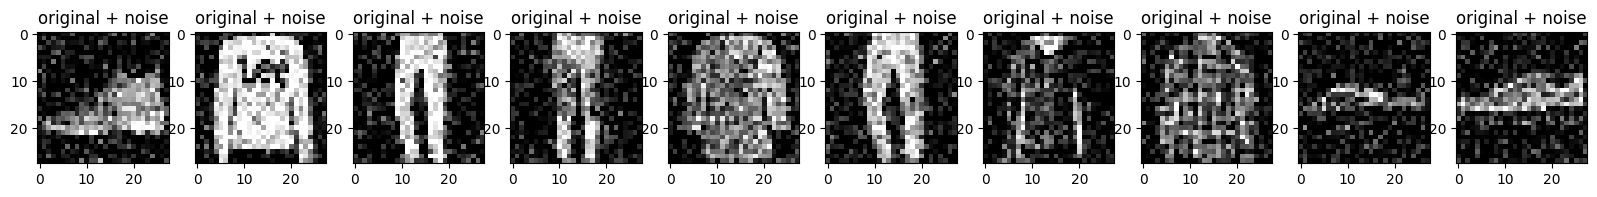

In [ ]:
n = 10
plt.figure(figsize=(20, 2))
for i in range(n):
    ax = plt.subplot(1, n, i + 1)
    plt.title("original + noise")
    plt.imshow(tf.squeeze(x_test_noisy[i]))
    plt.gray()
plt.show()

In [ ]:
class Denoise(Model):
    def __init__(self):
        super(Denoise, self).__init__()
        self.encoder = tf.keras.Sequential([
          layers.Input(shape=(28, 28, 1)),
          layers.Conv2D(16, (3, 3), activation='relu', padding='same', strides=2),
          layers.Conv2D(8, (3, 3), activation='relu', padding='same', strides=2)])

        self.decoder = tf.keras.Sequential([
          layers.Conv2DTranspose(8, kernel_size=3, strides=2, activation='relu', padding='same'),
          layers.Conv2DTranspose(16, kernel_size=3, strides=2, activation='relu', padding='same'),
          layers.Conv2D(1, kernel_size=(3, 3), activation='sigmoid', padding='same')])

    def call(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


In [ ]:
autoencoder = Denoise()

In [ ]:
autoencoder.compile(optimizer='adam', loss=losses.MeanSquaredError())

In [ ]:
# Train for 30 epochs and keep the History object for the loss curves
history = autoencoder.fit(x_train_noisy, x_train,
                epochs=30,
                shuffle=True,
                validation_data=(x_test_noisy, x_test))

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - loss: 0.0157 - val_loss: 0.0093
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0086 - val_loss: 0.0081
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0078 - val_loss: 0.0076
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0073 - val_loss: 0.0072
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0071 - val_loss: 0.0070
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0069 - val_loss: 0.0069
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0068 - val_loss: 0.0067
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.0067 - val_loss: 0.0067
Epoch 9/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0066 - val_loss: 0.0066
Epoch 10/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0066 - val_loss: 0.0066
Epoch 11/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0065 - val_loss: 0.0065
Epoch 12/30
1875/1875 ━━━━━━

In [ ]:
autoencoder.encoder.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 8)        │         1,160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,320 (5.16 KB)

 Trainable params: 1,320 (5.16 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
autoencoder.decoder.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_transpose                │ (32, 14, 14, 8)        │           584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (32, 28, 28, 16)       │         1,168 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (32, 28, 28, 1)        │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,897 (7.41 KB)

 Trainable params: 1,897 (7.41 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
encoded_imgs = autoencoder.encoder(x_test_noisy).numpy()
decoded_imgs = autoencoder.decoder(encoded_imgs).numpy()

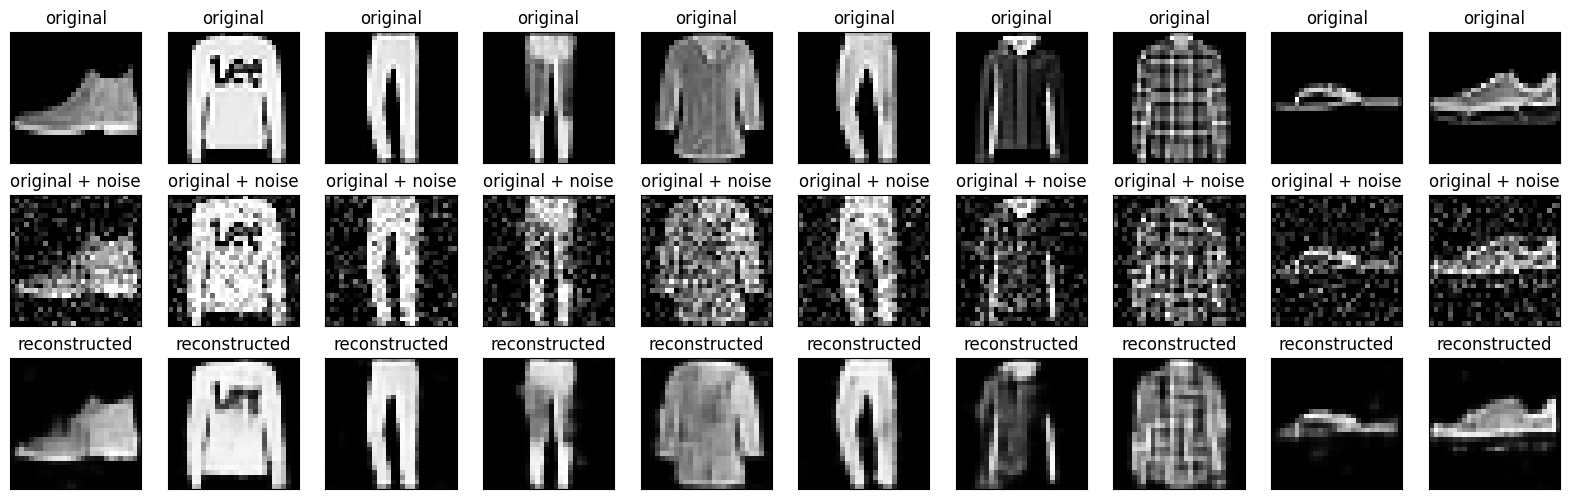

In [ ]:
n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    # display original
    ax = plt.subplot(3, n, i + 1)
    plt.title("original")
    plt.imshow(tf.squeeze(x_test[i]))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # display original + noise
    ax = plt.subplot(3, n, i + n + 1)
    plt.title("original + noise")
    plt.imshow(tf.squeeze(x_test_noisy[i]))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # display reconstruction
    bx = plt.subplot(3, n, i + 2*n + 1)
    plt.title("reconstructed")
    plt.imshow(tf.squeeze(decoded_imgs[i]))
    plt.gray()
    bx.get_xaxis().set_visible(False)
    bx.get_yaxis().set_visible(False)
plt.show()

### Test-set loss (Mean Squared Error)
Noisy test images are fed in; the output is compared with the **clean** test images.

In [ ]:
# MSE computed by Keras on the test set
test_mse = autoencoder.evaluate(x_test_noisy, x_test, verbose=0)
print(f"Test MSE (model.evaluate): {test_mse:.6f}")

# Same metric computed manually: mean of squared pixel differences
reconstructed = autoencoder.predict(x_test_noisy, verbose=0)
manual_mse = np.mean(np.square(np.asarray(x_test) - reconstructed))
print(f"Test MSE (manual numpy)  : {manual_mse:.6f}")

Test MSE (model.evaluate): 0.006314
Test MSE (manual numpy)  : 0.006314


In [ ]:
# For comparison with the Vanilla CNN AE: reconstruct the *clean* test images
clean_test_mse = autoencoder.evaluate(x_test, x_test, verbose=0)
print(f"Test MSE on clean inputs : {clean_test_mse:.6f}")

# How much noise was in the input before denoising (baseline error)
noise_mse = np.mean(np.square(np.asarray(x_test_noisy) - np.asarray(x_test)))
print(f"MSE of noisy input vs clean (before denoising): {noise_mse:.6f}")

Test MSE on clean inputs : 0.004254
MSE of noisy input vs clean (before denoising): 0.025507


### Training vs validation loss

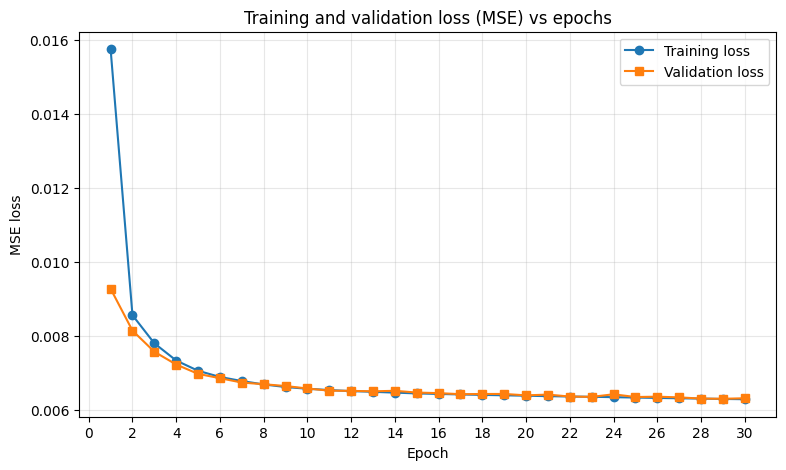

Final training loss  : 0.006288
Final validation loss: 0.006314


In [ ]:
epochs_range = range(1, len(history.history['loss']) + 1)

plt.figure(figsize=(9, 5))
plt.plot(epochs_range, history.history['loss'], 'o-', label='Training loss')
plt.plot(epochs_range, history.history['val_loss'], 's-', label='Validation loss')
plt.title('Training and validation loss (MSE) vs epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.xticks(range(0, len(epochs_range) + 1, 2))
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print(f"Final training loss  : {history.history['loss'][-1]:.6f}")
print(f"Final validation loss: {history.history['val_loss'][-1]:.6f}")

## Experiment: choosing `noise_factor`
Each noise level is (1) visualised on the same test images and (2) used to train a fresh `Denoise` model for 10 epochs.
For every model we record the denoising error (noisy test input → clean target), the error on clean test inputs and the train/validation gap.

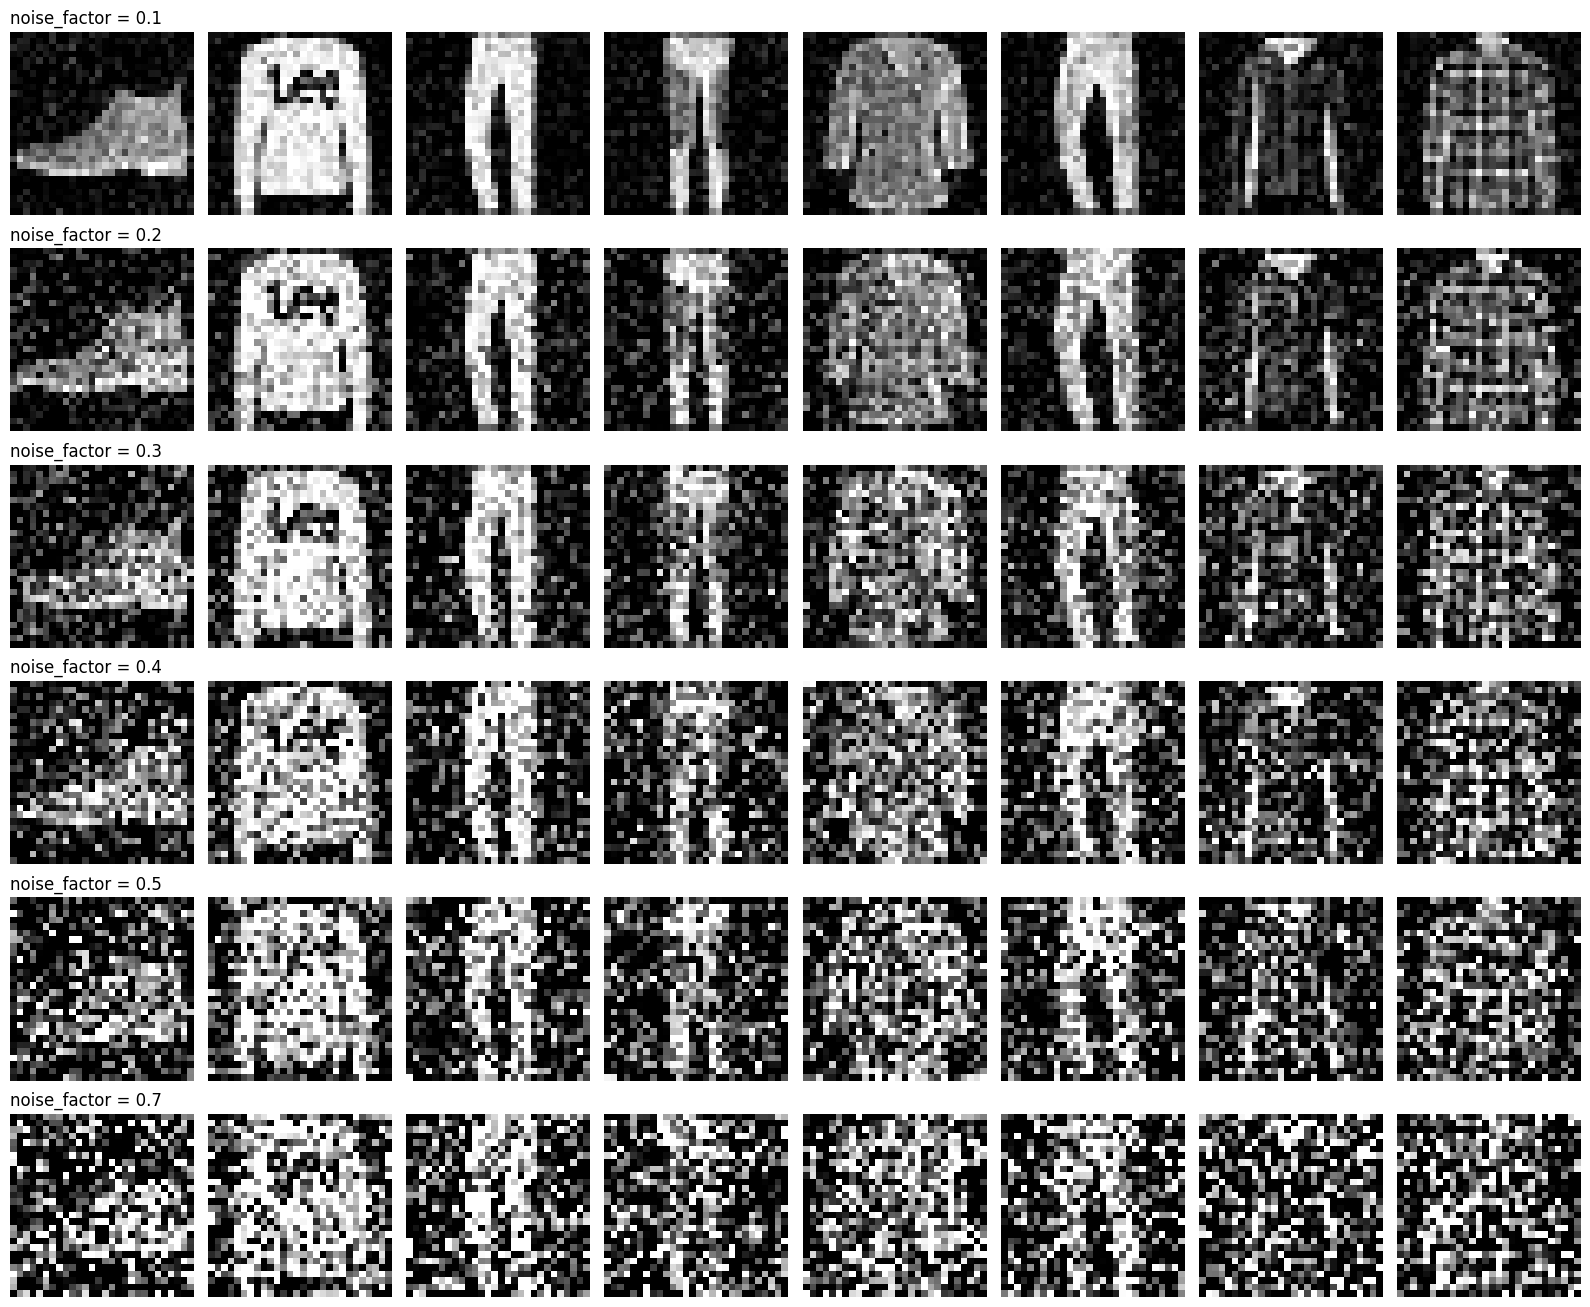

In [ ]:
noise_factors = [0.1, 0.2, 0.3, 0.4, 0.5, 0.7]

# 1) How each noise level affects the images
n = 8
plt.figure(figsize=(2 * n, 2.2 * len(noise_factors)))
for r, nf in enumerate(noise_factors):
    noisy = tf.clip_by_value(x_test[:n] + nf * tf.random.normal(shape=x_test[:n].shape), 0., 1.)
    for i in range(n):
        ax = plt.subplot(len(noise_factors), n, r * n + i + 1)
        plt.imshow(tf.squeeze(noisy[i]))
        plt.gray()
        ax.axis('off')
        if i == 0:
            ax.set_title(f"noise_factor = {nf}", loc='left')
plt.tight_layout()
plt.show()

In [ ]:
# 2) Train a fresh model for each noise level and compare
results = []
for nf in noise_factors:
    tf.keras.utils.set_random_seed(42)
    xtr = tf.clip_by_value(x_train + nf * tf.random.normal(shape=x_train.shape), 0., 1.)
    xte = tf.clip_by_value(x_test + nf * tf.random.normal(shape=x_test.shape), 0., 1.)
    model = Denoise()
    model.compile(optimizer='adam', loss=losses.MeanSquaredError())
    h = model.fit(xtr, x_train, epochs=10, shuffle=True, validation_data=(xte, x_test), verbose=0)
    results.append({
        'noise_factor': nf,
        'train_loss': h.history['loss'][-1],
        'val_loss (noisy->clean)': h.history['val_loss'][-1],
        'clean_test_mse': model.evaluate(x_test, x_test, verbose=0),
        'train/val gap': h.history['val_loss'][-1] - h.history['loss'][-1],
    })
    print(f"noise_factor={nf}: done")

results_df = pd.DataFrame(results)
results_df

noise_factor=0.1: done
noise_factor=0.2: done
noise_factor=0.3: done
noise_factor=0.4: done
noise_factor=0.5: done
noise_factor=0.7: done


,noise_factor,train_loss,val_loss (noisy->clean),clean_test_mse,train/val gap
0,0.1,0.003948,0.003934,0.002834,-0.000014
1,0.2,0.006898,0.006880,0.004668,-0.000017
2,0.3,0.010416,0.010448,0.008758,0.000032
3,0.4,0.013991,0.014034,0.011488,0.000042
4,0.5,0.018159,0.018120,0.014796,-0.000040
5,0.7,0.026568,0.026464,0.022182,-0.000103


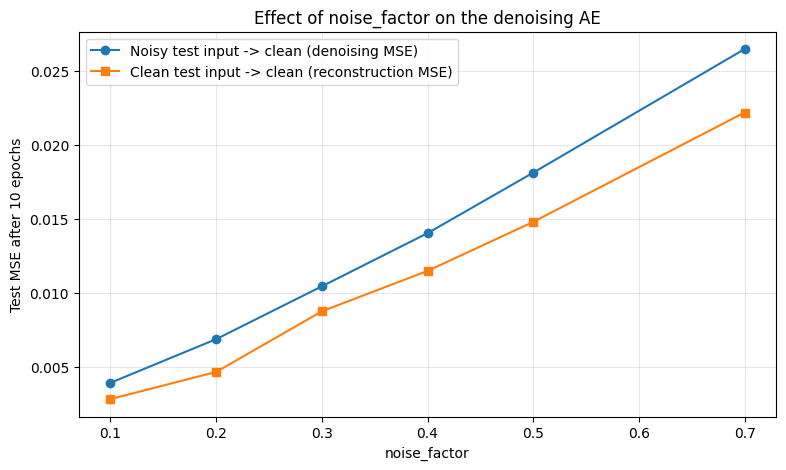

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(results_df['noise_factor'], results_df['val_loss (noisy->clean)'], 'o-', label='Noisy test input -> clean (denoising MSE)')
plt.plot(results_df['noise_factor'], results_df['clean_test_mse'], 's-', label='Clean test input -> clean (reconstruction MSE)')
plt.xlabel('noise_factor')
plt.ylabel('Test MSE after 10 epochs')
plt.title('Effect of noise_factor on the denoising AE')
plt.grid(alpha=0.3)
plt.legend()
plt.show()